In [7]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor

# 학습 모델 저장을 위한 라이브러리
import pickle

In [1]:
import pandas as pd

# 통합 파일 불러오기
df = pd.read_parquet(r'C:\Users\user\Desktop\빅데이터 분석 부트캠프\파이널프로젝트\data\통합데이터_with_Segment.parquet')

# Segment가 수치형인지 확인하고, 아니면 변환 (예: 'A', 'B', 'C' → 0, 1, 2)
if not pd.api.types.is_numeric_dtype(df['Segment']):
    df['Segment'] = df['Segment'].astype('category').cat.codes

# 수치형 컬럼만 필터링
numeric_df = df.select_dtypes(include=['number'])

# Segment와 상관계수 계산
correlations = numeric_df.corr()['Segment'].drop('Segment')

# 절댓값 기준 0.3 이상 필터링
selected_columns = correlations[correlations.abs() >= 0.3].index.tolist()

# 결과 출력
print("Segment와의 상관계수 >= 0.3인 컬럼 목록:")
print(selected_columns)

# 선택된 컬럼만 추출 (Segment 포함)
filtered_df = df[selected_columns + ['Segment']]


Segment와의 상관계수 >= 0.3인 컬럼 목록:
['201807_청구금액_B0', '201807_청구금액_R3M', '201807_청구금액_R6M', '201807_혜택수혜금액_R3M', '201807_혜택수혜금액', '201807_잔액_일시불_B0M', '201807_월중평잔_일시불_B0M', '201807_잔액_일시불_B1M', '201807_잔액_일시불_B2M', '201807_월중평잔_일시불', '201807_평잔_일시불_3M', '201807_평잔_일시불_6M', '201807_평잔_일시불_해외_6M', '201808_청구금액_B0', '201808_청구금액_R3M', '201808_청구금액_R6M', '201808_혜택수혜금액_R3M', '201808_혜택수혜금액', '201808_잔액_일시불_B0M', '201808_월중평잔_일시불_B0M', '201808_잔액_일시불_B1M', '201808_잔액_일시불_B2M', '201808_월중평잔_일시불', '201808_평잔_일시불_3M', '201808_평잔_일시불_6M', '201808_평잔_일시불_해외_6M', '201809_청구금액_B0', '201809_청구금액_R3M', '201809_청구금액_R6M', '201809_혜택수혜금액_R3M', '201809_혜택수혜금액', '201809_잔액_일시불_B0M', '201809_월중평잔_일시불_B0M', '201809_잔액_일시불_B1M', '201809_잔액_일시불_B2M', '201809_월중평잔_일시불', '201809_평잔_일시불_3M', '201809_평잔_일시불_6M', '201809_평잔_일시불_해외_6M', '201810_청구금액_B0', '201810_청구금액_R3M', '201810_청구금액_R6M', '201810_혜택수혜금액_R3M', '201810_혜택수혜금액', '201810_잔액_일시불_B0M', '201810_월중평잔_일시불_B0M', '201810_잔액_일시불_B1M', '201810_잔액_일시불_B2M', '20

In [2]:
filtered_df

,201807_청구금액_B0,201807_청구금액_R3M,201807_청구금액_R6M,201807_혜택수혜금액_R3M,201807_혜택수혜금액,201807_잔액_일시불_B0M,201807_월중평잔_일시불_B0M,201807_잔액_일시불_B1M,201807_잔액_일시불_B2M,201807_월중평잔_일시불,...,201812_잔액_일시불_B0M,201812_월중평잔_일시불_B0M,201812_잔액_일시불_B1M,201812_잔액_일시불_B2M,201812_월중평잔_일시불,201812_평잔_일시불_3M,201812_평잔_일시불_해외_3M,201812_평잔_일시불_6M,201812_평잔_일시불_해외_6M,Segment
0,12226,46588,88693,3,0,998,1084,736,1083,1503,...,687,850,568,554,1035,1433,0,2337,0,3
1,5834,10530,16861,0,0,2565,4090,6795,1424,4447,...,2264,2222,2253,2898,2399,2621,0,2865,0,4
2,21866,85931,165221,121,50,5312,5006,5150,6143,5540,...,7303,10580,9797,4369,8091,6211,0,7522,0,2
3,16356,61518,127371,3,2,730,487,462,708,606,...,1479,689,960,1018,1149,1985,0,2205,0,3
4,0,0,155,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
399996,28825,79682,194915,403,122,6374,10598,12113,6533,11321,...,3351,4412,4142,4362,5515,9424,0,12524,0,3
399997,3911,15577,32803,0,0,2168,1831,845,1743,2144,...,2524,2694,1523,2898,3046,2998,0,3241,0,2
399998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4


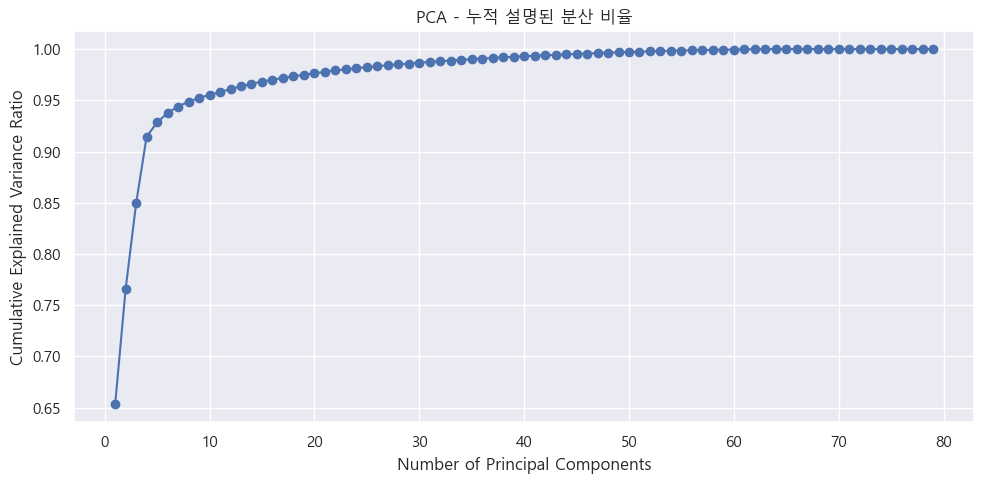

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Segment 제외한 피처만 추출
X = filtered_df.drop(columns=['Segment'])

# 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA 수행 (설명된 분산 비율을 보기 위해 모든 컴포넌트 유지)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# explained variance ratio 확인
explained_var_ratio = pca.explained_variance_ratio_

# 누적 분산도 계산
cumulative_var_ratio = explained_var_ratio.cumsum()

# 시각화
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_var_ratio) + 1), cumulative_var_ratio, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('PCA - 누적 설명된 분산 비율')
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
pca_n = PCA(n_components=8)
X_pca_reduced = pca_n.fit_transform(X_scaled)


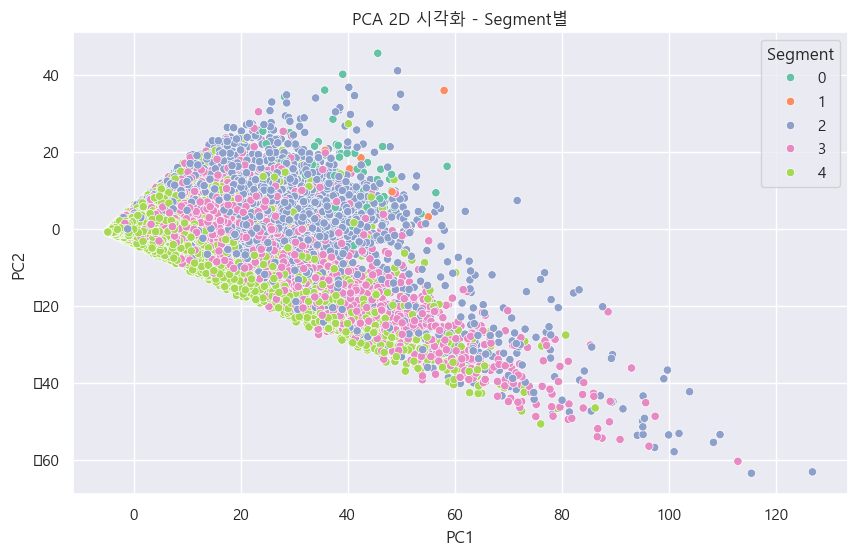

In [13]:
import seaborn as sns

pca_2 = PCA(n_components=2)
X_pca_2d = pca_2.fit_transform(X_scaled)

# 결과를 DataFrame으로
pca_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
pca_df['Segment'] = filtered_df['Segment'].values

# 시각화
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Segment', palette='Set2')
plt.title('PCA 2D 시각화 - Segment별')
plt.grid(True)
plt.show()


In [15]:
# PCA 수행
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
pca.fit(X_scaled)

# 각 주성분의 설명력
print("각 주성분의 설명력:", pca.explained_variance_ratio_)

# 누적 설명력
print("누적 설명력:", pca.explained_variance_ratio_.cumsum())


각 주성분의 설명력: [0.652998   0.11283645 0.083498   0.06509737 0.01395224 0.00930264
 0.00626983 0.00476156 0.0036028  0.00299439]
누적 설명력: [0.652998   0.76583445 0.84933245 0.91442983 0.92838206 0.93768471
 0.94395454 0.9487161  0.9523189  0.95531329]


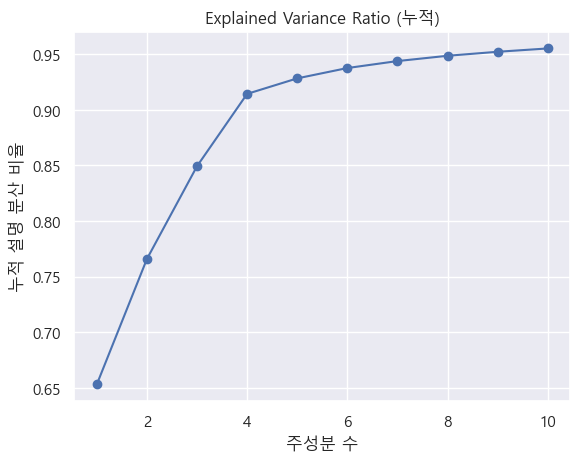

In [17]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel('주성분 수')
plt.ylabel('누적 설명 분산 비율')
plt.title('Explained Variance Ratio (누적)')
plt.grid(True)
plt.show()


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

# 1. Segment 제외하고 피처만 추출
X = filtered_df.drop(columns=['Segment'])

# 2. 스케일링 (PCA 전 필수)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. PCA - 주성분 4개로 축소
pca = PCA(n_components=4)
X_pca_4 = pca.fit_transform(X_scaled)

# 4. 결과를 DataFrame으로 변환
pca_df = pd.DataFrame(X_pca_4, columns=['PC1', 'PC2', 'PC3', 'PC4'])

# 5. Segment 다시 붙이기
pca_df['Segment'] = filtered_df['Segment'].values

# 6. 결과 저장 (선택)
pca_df

,PC1,PC2,PC3,PC4,Segment
0,-0.120954,3.417471,-5.261783,-0.415935,3
1,-1.741689,-1.408766,-0.851747,-0.160042,4
2,7.142277,5.191606,-7.439496,-1.659425,2
3,1.272838,5.408305,-6.710641,-0.847039,3
4,-4.782268,-0.889527,0.177357,0.067783,4
...,...,...,...,...,...
399995,-4.791334,-0.886819,0.178722,0.068049,4
399996,6.708657,4.106263,-3.612251,-1.817848,3
399997,-1.085566,-0.090535,-2.110276,-0.276070,2
399998,-4.791334,-0.886819,0.178722,0.068049,4


In [ ]:
# 6. 결과 저장 (선택)
pca_df.to_parquet(r'C:\Users\user\Desktop\빅데이터 분석 부트캠프\파이널프로젝트\PCA_4차원_데이터.parquet', index=False)

print("✅ 주성분 4개로 축소 완료! 결과 저장됨.")